In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn 
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [4]:
df.head()


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [5]:
df.columns.str.lower()

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [6]:
df.columns.str.lower().str.replace(' ', '_')

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

df.columns = df.columns.str.lower().str.replace(' ', '_')


In [7]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [8]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [9]:
df.dtypes[df.dtypes == 'object']

Series([], dtype: object)

In [10]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

[]

In [11]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')
    

In [12]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [13]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [14]:
df = df.drop(columns=['origin','fuel_type','drivetrain','num_doors','num_cylinders','acceleration'])
df

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0
...,...,...,...,...,...
9995,2005,2470,271.0,4690,27.4
9996,1993,2300,244.0,4370,30.0
9997,2014,2480,267.0,4590,28.1
9998,2004,2180,270.0,4450,32.2


In [15]:
df.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

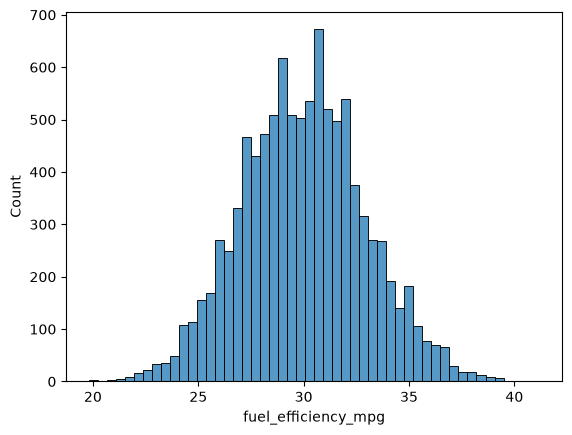

In [16]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

In [17]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

model_year
[2006 2008 1996 1989 1994]
50

engine_displacement
[2180 2390 2320 2130 2580]
127

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



In [18]:
# splitting the data 
n = len(df)
n_valid = int(n*0.2)
n_test = int(n*0.2)
n_train =n-n_valid-n_test



In [19]:
df_val = df.iloc[:n_valid]
df_test = df.iloc[n_valid:n_valid + n_test]
df_train =df.iloc[n_valid +n_test]
df_train

model_year             1980.0
engine_displacement    2450.0
horsepower              262.0
vehicle_weight         4530.0
fuel_efficiency_mpg      24.8
Name: 4000, dtype: float64

In [20]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_valid = df.iloc[idx[n_train:n_train + n_valid]]
df_test = df.iloc[idx[n_train + n_valid:]]
df_test

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
399,1981,2370,268.0,4410,27.8
7247,2020,2240,256.0,4220,37.3
6406,2023,2090,217.0,3910,33.1
882,2021,2280,251.0,4420,31.3
3565,1979,2450,256.0,4420,26.4
...,...,...,...,...,...
5734,1988,2100,257.0,4130,30.7
5191,2000,2160,231.0,4180,25.5
5390,2013,2430,246.0,4660,30.1
860,2014,2450,307.0,4500,30.5


In [21]:
df['horsepower'] = df['horsepower'].fillna(0)
df['horsepower']

0       243.0
1       272.0
2       267.0
3       258.0
4       304.0
        ...  
9995    271.0
9996    244.0
9997    267.0
9998    270.0
9999    295.0
Name: horsepower, Length: 10000, dtype: float64

In [22]:
idx = np.arange(n)
np.random.shuffle(idx)

In [23]:
df_train = df.iloc[idx[:n_train]]
df_valid = df.iloc[idx[n_train:n_train+n_valid]]
df_test = df.iloc[idx[n_train+n_valid:]]

In [24]:
df_test

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
9204,2002,2660,293.0,4740,24.7
6833,2023,2360,272.0,4400,28.5
8316,1989,1970,238.0,4220,31.1
644,2000,1880,201.0,4060,30.8
597,1984,2180,252.0,4500,25.6
...,...,...,...,...,...
1690,2006,2320,260.0,4430,31.0
625,1983,1860,216.0,3870,34.0
7523,1986,2210,270.0,4280,29.4
5830,2007,2570,286.0,4660,27.3


In [25]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [26]:
df_train = df_train.reset_index(drop=True)
df_valid = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [27]:
df_valid

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0
...,...,...,...,...,...
1995,1976,2390,NaN,4090,29.6
1996,1999,2110,252.0,4270,28.0
1997,1983,1960,226.0,4240,27.7
1998,2021,2330,278.0,4480,32.9


In [28]:
#preparing the target varianle 
y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)
y_val

array([3.49347266, 3.47506723, 3.34990409, ..., 3.35689712, 3.52341501,
       3.53514535], shape=(2000,))

In [29]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [30]:
#training the data with linear regresion using xi as model for index 3

In [31]:
xi = [2390, 272,4210] #
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [32]:
def linear_regression (xi):
    n = len(xi)
    pred = w0
    for j in range(n):
        pred = pred + w[j] * xi[j]
        return(pred)


In [33]:
linear_regression(xi)

31.07

In [34]:
np.expm1(31.07)

np.float64(31155128922000.68)

In [36]:
df_train.columns

Index(['model_year', 'engine_displacement', 'horsepower', 'vehicle_weight'], dtype='str')

In [39]:
base = ['model_year','engine_displacement','horsepower','vehicle_weight']
x_train =df_train[base].values
x_train

array([[1996., 1770.,  202., 3550.],
       [2013., 2440.,  286., 4500.],
       [1986., 1990.,  217., 3530.],
       ...,
       [1981., 2180.,    0., 4480.],
       [1986., 2330.,  260., 4220.],
       [1979., 2360.,  271., 4290.]], shape=(6000, 4))

In [41]:
#training the data 
wo, w = train_linear_regression(x_train,y_train)

NameError: name 'train_linear_regression' is not defined